<a href="https://colab.research.google.com/github/suryasridhar/regime-detection-and-optimization/blob/feature%2Fhmm/ETF_HMM_Regime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
!pip install yfinance
!pip install pandas

In [99]:
!pip install numpy

In [100]:
!pip install scikit-learn

In [101]:
# 1. ETF Data Collection and Cleaning

import yfinance as yf
import pandas as pd
import numpy as np



In [102]:
# Define ETF universe
etfs = ["QQQ", "DIA", "IWM"]
base_etf = ["SPY"]
# Define time range
start_date = "2020-01-01"
end_date = "2024-12-31"

In [103]:
# Download adjusted close prices
raw_data = yf.download(etfs, start=start_date, end=end_date, auto_adjust=False)
base_data = yf.download(base_etf, start_date, end_date, auto_adjust=False)['Adj Close']
adj_close = pd.DataFrame(raw_data['Adj Close'])
raw_data.head()

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


Price        Adj Close                               Close              \
Ticker             DIA         IWM         QQQ         DIA         IWM   
Date                                                                     
2020-01-02  260.296478  154.658905  209.091080  288.619995  165.779999   
2020-01-03  258.222137  154.052536  207.175812  286.320007  165.130005   
2020-01-06  258.817505  154.257751  208.510696  286.980011  165.350006   
2020-01-07  257.699036  153.744659  208.481705  285.739990  164.800003   
2020-01-08  259.196075  154.220413  210.048706  287.399994  165.309998   

Price                         High                                 Low  \
Ticker             QQQ         DIA         IWM         QQQ         DIA   
Date                                                                     
2020-01-02  216.160004  288.630005  166.750000  216.160004  286.149994   
2020-01-03  214.179993  287.109985  165.410004  215.470001  285.179993   
2020-01-06  215.559998  287.029999  165.539993  215.589996  284.160004   
2020-01-07  215.529999  286.790009  165.339996  216.139999  285.579987   
2020-01-08  217.149994  288.670013  166.029999  218.139999  285.079987   

Price                                     Open                          \
Ticker             IWM         QQQ         DIA         IWM         QQQ   
Date                                                                     
2020-01-02  164.229996  213.979996  286.440002  166.740005  214.399994   
2020-01-03  163.699997  213.279999  285.339996  163.740005  213.300003   
2020-01-06  163.539993  212.240005  284.290009  163.850006  212.500000   
2020-01-07  164.210007  214.850006  286.299988  164.850006  215.639999   
2020-01-08  164.720001  215.160004  285.320007  164.820007  215.500000   

Price        Volume                      
Ticker          DIA       IWM       QQQ  
Date                                     
2020-01-02  3865500  18297500  30969400  
2020-01-03  3296700  19295600  27518900  
2020-01-06  1645100  17150900  21655300  
2020-01-07  1413000  11817900  22139300  
2020-01-08  3136700  13832400  26397300

In [104]:
#Setup multiindex data
data = adj_close.dropna()
multi_cols = pd.MultiIndex.from_product([etfs, ['adj_close']], names=('ticker','feature'))
data.columns = multi_cols
data

ticker,QQQ,DIA,IWM
feature,adj_close,adj_close,adj_close
Date,,,
2020-01-02,260.296478,154.658905,209.091080
2020-01-03,258.222137,154.052536,207.175812
2020-01-06,258.817505,154.257751,208.510696
2020-01-07,257.699036,153.744659,208.481705
2020-01-08,259.196075,154.220413,210.048706
...,...,...,...
2024-12-23,425.102356,220.305115,521.505737
2024-12-24,428.680481,222.275223,528.577271


In [105]:
#Get log returns and gets log return relative to SPY
returns = np.log(data / data.shift(1)).dropna()
base_etf_log_returns = np.log(base_data / base_data.shift(1)).dropna()['SPY']
returns_relative = returns.sub(base_etf_log_returns, axis=0)

for ticker in etfs:
    data[(ticker, 'log_return')] = returns[ticker]
    data[(ticker, 'relative_spy')] = returns_relative[ticker]
data.head()


ticker             QQQ         DIA         IWM        QQQ               \
feature      adj_close   adj_close   adj_close log_return relative_spy   
Date                                                                     
2020-01-02  260.296478  154.658905  209.091080        NaN          NaN   
2020-01-03  258.222137  154.052536  207.175812  -0.008001    -0.000400   
2020-01-06  258.817505  154.257751  208.510696   0.002303    -0.001505   
2020-01-07  257.699036  153.744659  208.481705  -0.004331    -0.001515   
2020-01-08  259.196075  154.220413  210.048706   0.005792     0.000477   

ticker            DIA                     IWM               
feature    log_return relative_spy log_return relative_spy  
Date                                                        
2020-01-02        NaN          NaN        NaN          NaN  
2020-01-03  -0.003928     0.003673  -0.009202    -0.001601  
2020-01-06   0.001331    -0.002477   0.006423     0.002615  
2020-01-07  -0.003332    -0.000516  -0.000139     0.002677  
2020-01-08   0.003090    -0.002226   0.007488     0.002172

In [106]:
#Get ATR with 14-day moving average
prev_close = data.xs('adj_close', level = 1, axis =1).shift(1)
p1 = (raw_data['High'] - raw_data['Low']).dropna()
p2 = abs(raw_data['High'] - prev_close)
p3 = abs(prev_close - raw_data['Low'])
tr_df = pd.concat([p1, p2, p3], axis=1, keys=['HL_range', 'High_prev', 'Prev_Low']).swaplevel(axis=1).dropna()
atr = pd.DataFrame({ticker: tr_df[ticker].max(axis=1) for ticker in etfs}).rolling(window=14).mean()
for ticker in etfs:
    data[(ticker, 'atr')] = atr[ticker]


In [107]:
#Volume z-score
vol_data = raw_data['Volume']
volume_z = (vol_data - vol_data.rolling(window=20).mean())/vol_data.rolling(window=20).std()
for ticker in etfs:
    data[(ticker, 'volume_z')] = volume_z[ticker]


In [108]:
#skew, kurtosis, rolling mean
skew_returns = returns.rolling(14).skew()
kurtosis_returns = returns.rolling(14).kurt()
mean_rolling = returns.rolling(14).mean()
for ticker in etfs:
  data[(ticker, 'skew_returns')] = skew_returns[ticker]
  data[(ticker, 'kurtosis_returns')] = kurtosis_returns[ticker]
  data[(ticker, 'rolling_mean')] = mean_rolling[ticker]
data

ticker             QQQ         DIA         IWM        QQQ               \
feature      adj_close   adj_close   adj_close log_return relative_spy   
Date                                                                     
2020-01-02  260.296478  154.658905  209.091080        NaN          NaN   
2020-01-03  258.222137  154.052536  207.175812  -0.008001    -0.000400   
2020-01-06  258.817505  154.257751  208.510696   0.002303    -0.001505   
2020-01-07  257.699036  153.744659  208.481705  -0.004331    -0.001515   
2020-01-08  259.196075  154.220413  210.048706   0.005792     0.000477   
...                ...         ...         ...        ...          ...   
2024-12-23  425.102356  220.305115  521.505737   0.000816    -0.005154   
2024-12-24  428.680481  222.275223  528.577271   0.008382    -0.002672   
2024-12-26  429.384186  224.553787  528.218201   0.001640     0.001574   
2024-12-27  426.202545  221.280228  521.196533  -0.007437     0.003145   
2024-12-30  422.009888  219.578751  514.264648  -0.009886     0.001591   

ticker            DIA                     IWM                     QQQ  ...  \
feature    log_return relative_spy log_return relative_spy        atr  ...   
Date                                                                   ...   
2020-01-02        NaN          NaN        NaN          NaN        NaN  ...   
2020-01-03  -0.003928     0.003673  -0.009202    -0.001601        NaN  ...   
2020-01-06   0.001331    -0.002477   0.006423     0.002615        NaN  ...   
2020-01-07  -0.003332    -0.000516  -0.000139     0.002677        NaN  ...   
2020-01-08   0.003090    -0.002226   0.007488     0.002172        NaN  ...   
...               ...          ...        ...          ...        ...  ...   
2024-12-23  -0.002301    -0.008271   0.009696     0.003725  94.001354  ...   
2024-12-24   0.008903    -0.002151   0.013469     0.002415  95.721586  ...   
2024-12-26   0.010199     0.010132  -0.000680    -0.000746  97.449408  ...   
2024-12-27  -0.014685    -0.004103  -0.013382    -0.002800  98.433149  ...   
2024-12-30  -0.007719     0.003758  -0.013389    -0.001912  99.056850  ...   

ticker           IWM          QQQ                                        DIA  \
feature     volume_z skew_returns kurtosis_returns rolling_mean skew_returns   
Date                                                                           
2020-01-02       NaN          NaN              NaN          NaN          NaN   
2020-01-03       NaN          NaN              NaN          NaN          NaN   
2020-01-06       NaN          NaN              NaN          NaN          NaN   
2020-01-07       NaN          NaN              NaN          NaN          NaN   
2020-01-08       NaN          NaN              NaN          NaN          NaN   
...              ...          ...              ...          ...          ...   
2024-12-23  0.144345    -1.270837         4.960230    -0.002890    -2.084122   
2024-12-24 -1.112565    -1.177941         4.611115    -0.002776    -1.948520   
2024-12-26 -0.553218    -1.337542         4.799822    -0.002299    -2.039325   
2024-12-27 -0.015682    -1.192037         4.178478    -0.002587    -1.718777   
2024-12-30 -0.159339    -1.013393         3.278112    -0.002962    -1.665659   

ticker                                            IWM                   \
feature    kurtosis_returns rolling_mean skew_returns kurtosis_returns   
Date                                                                     
2020-01-02              NaN          NaN          NaN              NaN   
2020-01-03              NaN          NaN          NaN              NaN   
2020-01-06              NaN          NaN          NaN              NaN   
2020-01-07              NaN          NaN          NaN              NaN   
2020-01-08              NaN          NaN          NaN              NaN   
...                     ...          ...          ...              ...   
2024-12-23         5.900623    -0.005556    -1.518532         3.478583   
2024-12-2

In [140]:
#Flattening it out in prep for HMM
features = ['log_return', 'atr', 'relative_spy', 'atr', 'volume_z', 'skew_returns', 'kurtosis_returns', 'rolling_mean']
flattened_standard = pd.concat(
    [data[ticker][features] for ticker in etfs],
    axis=1,
    keys=etfs
)

# rename to ticker_feature format
flattened_standard.columns = [
    f"{ticker}_{feature}" for ticker in etfs for feature in features
]

# drop rows with NaN


In [130]:
#vix
# vix = yf.download('^VIX', start=start_date, end=end_date, auto_adjust=False)['Adj Close']
# vix = vix.loc[flattened_standard.index]
# flattened_standard['vix'] = vix.values
# flattened_standard = flattened_standard.dropna()

[*********************100%***********************]  1 of 1 completed


# Markov Model for identifying low or high volatility regimes

In [147]:
flattened_standard = flattened_standard.dropna()



In [148]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scale = scaler.fit_transform(flattened_standard)
X_scale = pd.DataFrame(X_scale, index = flattened_standard.index, columns = flattened_standard.columns)

In [149]:
from sklearn.decomposition import PCA
pca = PCA()
data_with_pca = pca.fit_transform(X_scale)
print(pca.explained_variance_ratio_)

[2.21334107e-01 1.73025244e-01 9.76662099e-02 9.38142096e-02
 8.85276535e-02 6.97248524e-02 5.34297847e-02 3.49094575e-02
 3.37025509e-02 2.68996211e-02 2.03249971e-02 1.84523916e-02
 1.48903349e-02 1.30771883e-02 1.11066786e-02 1.02788532e-02
 9.12989166e-03 5.75170415e-03 3.95427068e-03 3.02483694e-17
 9.76669064e-18 5.10682219e-18 5.38343394e-19 0.00000000e+00]


In [150]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
k = np.argmax(cum_var > 0.9) + 1
data_with_pca_reduced = data_with_pca[:, :k]
data_with_pca_reduced = pd.DataFrame(data_with_pca_reduced)
data_with_pca_reduced.index = flattened_standard.index

In [151]:
data_with_pca_reduced

,0,1,2,3,4,5,6,7,8,9,10
Date,,,,,,,,,,,
2020-01-30,-1.768214,-1.617237,2.649271,0.016921,0.069561,0.721882,-0.812022,-0.597041,-0.810394,0.280615,-1.227062
2020-01-31,-1.873511,-4.197916,2.271943,0.362089,-0.686964,1.605563,-2.050827,0.165888,0.692905,1.137046,-0.778586
2020-02-03,-1.996360,0.191093,1.831245,1.599351,-0.375663,-0.643786,-0.050665,-0.088622,0.043931,1.240403,-0.861971
2020-02-04,-2.001816,0.992656,1.532372,1.500650,0.134582,-0.197802,-0.300864,-0.008826,-0.727523,0.930190,-0.861872
2020-02-05,-1.924564,0.029040,1.506017,-1.127903,1.405920,-0.922626,-0.557539,-0.017470,-1.023138,0.554285,-0.748197
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,6.158066,-1.674882,4.254824,2.523805,-3.563407,-1.422962,1.926725,1.770579,-0.581950,1.000667,1.502281
2024-12-24,6.171754,-0.273379,3.811690,2.199464,-3.119751,-2.624590,2.560430,1.361049,-0.595033,1.012000,1.357747
2024-12-26,6.336680,-0.906221,4.418599,0.754576,-2.595928,-3.055409,2.386095,1.386265,0.459830,1.271424,1.410273


In [ ]:
#vix
vix = yf.download('^VIX', start=start_date, end=end_date, auto_adjust=False)['Adj Close']
vix = vix.loc[flattened_standard.index]
flattened_standard['vix'] = vix.values
flattened_standard = flattened_standard.dropna()

In [114]:
!pip install hmmlearn

In [139]:
from hmmlearn.hmm import GaussianHMM
n_states = 2
hmm_data = data_with_pca_reduced
model = GaussianHMM(
    n_components=n_states,
    covariance_type='full',
    n_iter=10000,
    tol = 1e-2,
    random_state=42
)
model.fit(hmm_data)
regimes = model.predict(X_scale_small)
state_probs = model.predict_proba(X_scale_small)
X_scale_small['regime'] = (regimes - 1)
X_scale_small

,QQQ_log_return,QQQ_atr,QQQ_relative_spy,QQQ_atr,QQQ_volume_z,QQQ_skew_returns,QQQ_kurtosis_returns,QQQ_rolling_mean,DIA_log_return,DIA_atr,...,IWM_log_return,IWM_atr,IWM_relative_spy,IWM_atr,IWM_volume_z,IWM_skew_returns,IWM_kurtosis_returns,IWM_rolling_mean,vix,regime
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-30,0.300052,0.159837,0.291386,0.159837,1.859812,-1.332754,1.049303,-0.189352,-0.016747,-0.721015,...,0.174888,-1.687368,0.023354,-1.687368,1.713558,-1.064034,1.125049,0.114697,-0.731472,-1
2020-01-31,-1.659381,0.156475,-0.695866,0.156475,2.634181,-1.834391,0.961460,-0.558493,-1.218036,-0.724641,...,-1.024561,-1.678200,0.348454,-1.678200,2.957349,-0.841739,0.122258,-0.131596,-0.326112,-1
2020-02-03,0.388773,0.136766,-0.409881,0.136766,-0.239624,-1.801256,0.865030,-0.497089,0.618834,-0.721256,...,0.877173,-1.674372,1.192481,-1.674372,-0.020066,-0.648925,0.044068,-0.066918,-0.431385,-1
2020-02-04,1.048995,0.106798,-0.184735,0.106798,0.286476,-1.223825,0.473848,-0.201604,0.841914,-0.716083,...,1.345804,-1.671736,1.177940,-1.671736,-0.324002,-0.307498,-0.018697,0.420657,-0.663710,-1
2020-02-05,1.231428,0.080016,1.231116,0.080016,1.032405,-0.772343,0.108879,0.076208,0.860106,-0.706641,...,0.158696,-1.662645,-1.342617,-1.662645,0.026008,-0.394352,0.015872,0.473543,-0.772613,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.032133,2.542684,-1.173862,2.542684,0.027642,-1.681775,3.170061,-1.007853,-0.148619,2.105494,...,0.551796,2.373292,0.570959,2.373292,0.126157,-1.886682,1.959535,0.056031,-0.575378,0
2024-12-24,0.607160,2.620002,-0.592407,2.620002,-0.876969,-1.549412,2.931435,-0.972944,0.493545,2.102509,...,0.783402,2.403856,0.360588,2.403856,-1.039364,-1.857005,1.905893,0.077709,-0.879095,0
2024-12-26,0.094747,2.697662,0.402001,2.697662,-0.717909,-1.776821,3.060419,-0.826619,0.567830,2.099505,...,-0.085055,2.432324,-0.147105,2.432324,-0.520686,-1.922633,2.002842,0.116152,-0.823434,0


In [116]:
print(model.transmat_)

[[9.09355102e-001 8.74678454e-002 3.17705307e-003]
 [5.52613770e-002 9.44738623e-001 2.92014421e-010]
 [5.25457474e-271 8.27389969e-215 1.00000000e+000]]


In [117]:
!pip install matplotlib

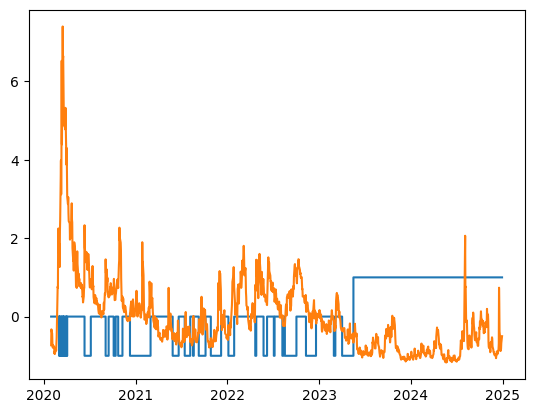

In [118]:
import matplotlib.pyplot as plt
latest = X_scale_small
plt.plot(latest.index, latest['regime'], drawstyle = 'steps-post')
plt.plot(latest.index, latest['vix'])